El aliasing es un fenómeno de distorsión que ocurre durante el muestreo digital de una señal analógica, como una imagen. Se produce cuando la frecuencia de muestreo es insuficiente para capturar correctamente los detalles finos de la señal original, violando el teorema de Nyquist-Shannon. En el contexto de las imágenes digitales, el aliasing se manifiesta visualmente como bordes escalonados ("jaggies") en líneas diagonales o curvas, y como la aparición de patrones de baja frecuencia que no existen en la realidad. Este efecto es particularmente notable al representar texturas de alta frecuencia, como un patrón de rayas muy juntas, donde el sensor no tiene suficiente resolución para distinguirlas individualmente, generando artefactos no deseados.

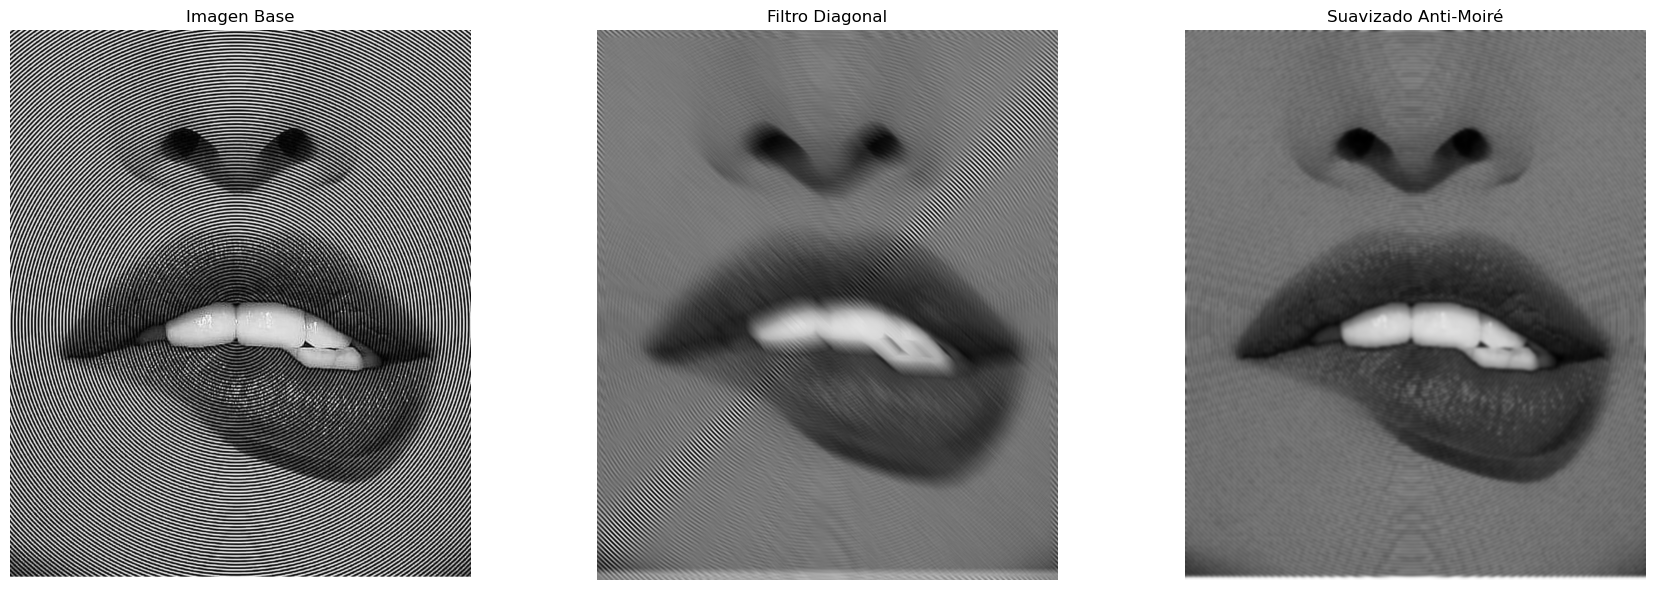

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def generar_matriz_diagonal(dim):
    matriz = np.zeros((dim, dim), dtype=np.float32)
    for fila in range(dim):
        matriz[fila, fila] = 1.0
    matriz = matriz / np.sum(matriz)
    return matriz

def aplicar_filtro_diagonal(imagen, dimension):
    kernel = generar_matriz_diagonal(dimension)
    resultado = cv2.filter2D(imagen.astype(np.float32), -1, kernel)
    resultado = np.clip(resultado, 0, 255).astype(np.uint8)
    return resultado

ruta_imagen = 'moire.png'
imagen_original = cv2.imread(ruta_imagen, 0)

if imagen_original is None:
    print(f"Error al cargar '{ruta_imagen}'. Creando imagen de prueba.")
    imagen_original = np.ones((512, 512), dtype=np.uint8) * 127
    cv2.randn(imagen_original, 127, 40) 

tamaño_kernel = 31

# Aplicar convolución diagonal
imagen_filtrada = aplicar_filtro_diagonal(imagen_original, tamaño_kernel)

# Suavizado para eliminar patrones Moiré
kernel_gauss = 15
imagen_sin_moire = cv2.GaussianBlur(imagen_original, (kernel_gauss, kernel_gauss), 0)

# Visualización de resultados
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(imagen_original, cmap='gray')
plt.title('Imagen Base')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(imagen_filtrada, cmap='gray')
plt.title('Filtro Diagonal')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(imagen_sin_moire, cmap='gray')
plt.title('Suavizado Anti-Moiré')
plt.axis('off')

plt.tight_layout()
plt.show()

El patrón de Moiré es un caso específico y muy común de aliasing visual. Se forma cuando dos patrones periódicos (como dos rejillas, telas o texturas) se superponen, ya sea en el mundo real o durante el proceso de digitalización. La interferencia entre ambas estructuras crea un nuevo patrón macroscópico de ondas, anillos o franjas que no estaban presentes originalmente. En fotografía y digitalización de imágenes, los patrones de Moiré aparecen con frecuencia al capturar objetos con texturas repetitivas y finas, como una camisa de vestir, un tejido de mezclilla o una pantalla de computadora. Este efecto es generalmente indeseado en la mayoría de las aplicaciones técnicas, pero se puede mitigar utilizando filtros ópticos antialiasing en las cámaras o aplicando técnicas de procesamiento digital como el filtrado pasa-bajas o el sobremuestreo.

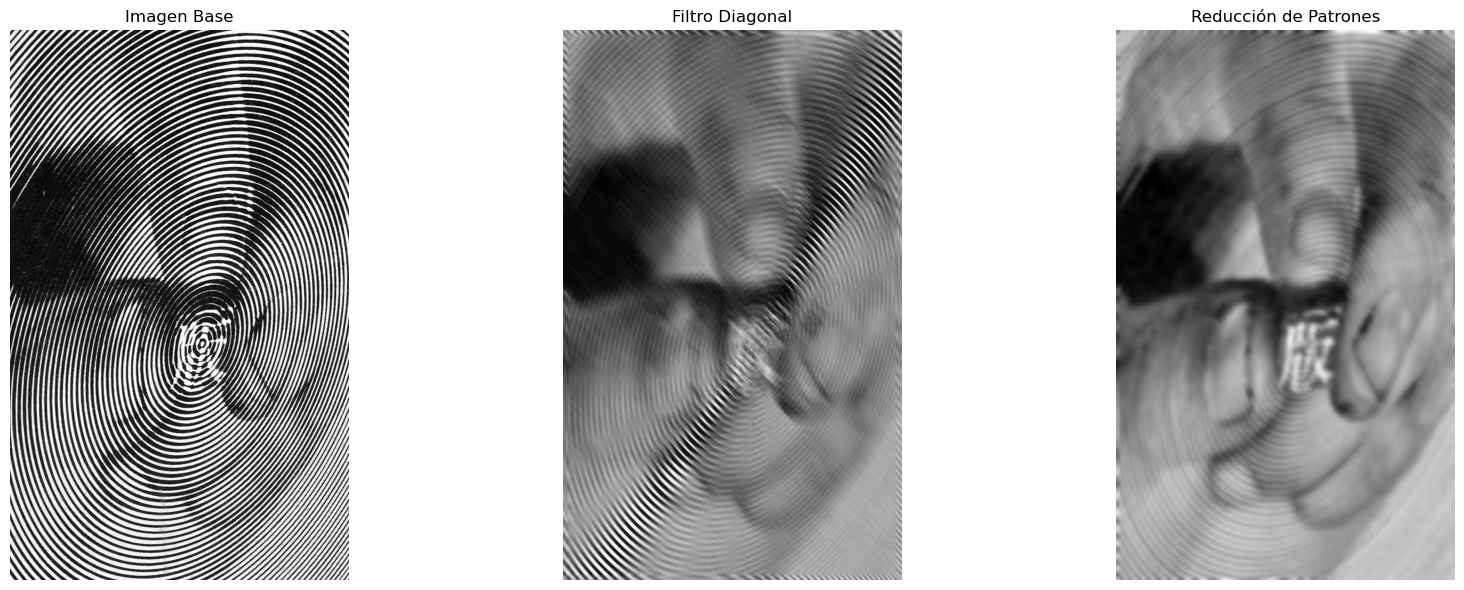

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def construir_kernel_diagonal(dim):
    matriz = np.zeros((dim, dim), dtype=np.float32)
    for i in range(dim):
        matriz[i, i] = 1.0
    matriz = matriz / np.sum(matriz)
    return matriz

def procesar_filtro_diagonal(imagen, dimension):
    kernel = construir_kernel_diagonal(dimension)
    resultado = cv2.filter2D(imagen.astype(np.float32), -1, kernel)
    resultado = np.clip(resultado, 0, 255).astype(np.uint8)
    return resultado

def reducir_patrones(imagen, factor=0.25, suavizado=35):
    imagen_suave = cv2.GaussianBlur(imagen, (suavizado, suavizado), 0)
    alto, ancho = imagen_suave.shape[:2]
    reducida = cv2.resize(imagen_suave, (int(ancho*factor), int(alto*factor)), interpolation=cv2.INTER_NEAREST)
    imagen_final = cv2.resize(reducida, (ancho, alto), interpolation=cv2.INTER_NEAREST)
    return imagen_final

ruta_archivo = 'aliasing.png'
imagen_base = cv2.imread(ruta_archivo, 0)

if imagen_base is None:
    print(f"No se pudo cargar '{ruta_archivo}'. Generando imagen de prueba.")
    imagen_base = np.ones((512, 512), dtype=np.uint8) * 127
    cv2.randn(imagen_base, 127, 40) 

dimension_kernel = 31
factor_escala = 0.25 
tamano_suave = 35 

# Aplicar procesamiento diagonal
imagen_procesada = procesar_filtro_diagonal(imagen_base, dimension_kernel)

# Aplicar reducción de patrones
imagen_sin_patrones = reducir_patrones(imagen_base, factor_escala, tamano_suave)

# Mostrar resultados
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(imagen_base, cmap='gray')
plt.title('Imagen Base')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(imagen_procesada, cmap='gray')
plt.title('Filtro Diagonal')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(imagen_sin_patrones, cmap='gray')
plt.title('Reducción de Patrones')
plt.axis('off')

plt.tight_layout()
plt.show()